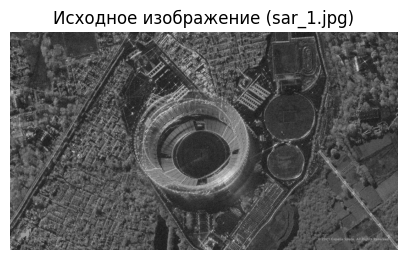

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import peak_signal_noise_ratio as psnr

img_path = 'sar_1.jpg' if os.path.exists('sar_1.jpg') else '/content/sar_1.jpg'
img_clean = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img_clean is None:
  raise FileNotFoundError(f'Файл {img_path} не найден!')

plt.figure(figsize=(5, 5))
plt.imshow(img_clean, cmap='gray')
plt.title('Исходное изображение (sar_1.jpg)')
plt.axis('off')
plt.show()

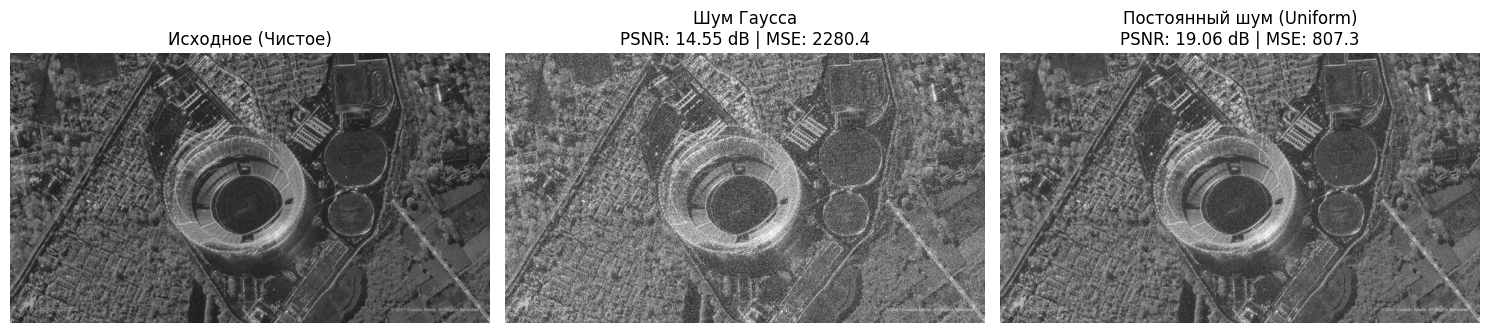

In [3]:
# 1. Шум Гаусса (нормальное распределение, положительные значения)
noise_gauss = np.zeros(img_clean.shape, dtype=np.uint8)
cv2.randn(noise_gauss, mean=30, stddev=40)
img_noisy_gauss = cv2.add(img_clean, noise_gauss)

# 2. Постоянный шум (равномерное распределение с постоянной плотностью, значения от 0 до 50)
noise_const = np.random.uniform(0, 50, img_clean.shape).astype(np.uint8)
img_noisy_const = cv2.add(img_clean, noise_const)

# Визуализация зашумленных изображений
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_clean, cmap='gray')
plt.title('Исходное (Чистое)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_noisy_gauss, cmap='gray')
plt.title(
    f'Шум Гаусса\nPSNR: {psnr(img_clean, img_noisy_gauss):.2f} dB | MSE:'
    f' {mse(img_clean, img_noisy_gauss):.1f}'
)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_noisy_const, cmap='gray')
plt.title(
    f'Постоянный шум (Uniform)\nPSNR: {psnr(img_clean, img_noisy_const):.2f}'
    f' dB | MSE: {mse(img_clean, img_noisy_const):.1f}'
)
plt.axis('off')

plt.tight_layout()
plt.show()

=== Результаты фильтрации: Шум Гаусса ===
Медианный (k=3)         : PSNR = 17.00 dB | MSE = 1295.96
Медианный (k=5)         : PSNR = 17.21 dB | MSE = 1235.44
Гаусс (3x3, s=1)        : PSNR = 16.53 dB | MSE = 1444.31
Гаусс (5x5, s=1.5)      : PSNR = 16.54 dB | MSE = 1442.36
Билатеральный (d=5)     : PSNR = 16.61 dB | MSE = 1420.84
Билатеральный (d=9)     : PSNR = 16.76 dB | MSE = 1372.11
NLM (h=10)              : PSNR = 14.55 dB | MSE = 2280.36
NLM (h=15)              : PSNR = 14.58 dB | MSE = 2264.55

-> Лучший фильтр для Гауссова шума: Медианный (k=5)



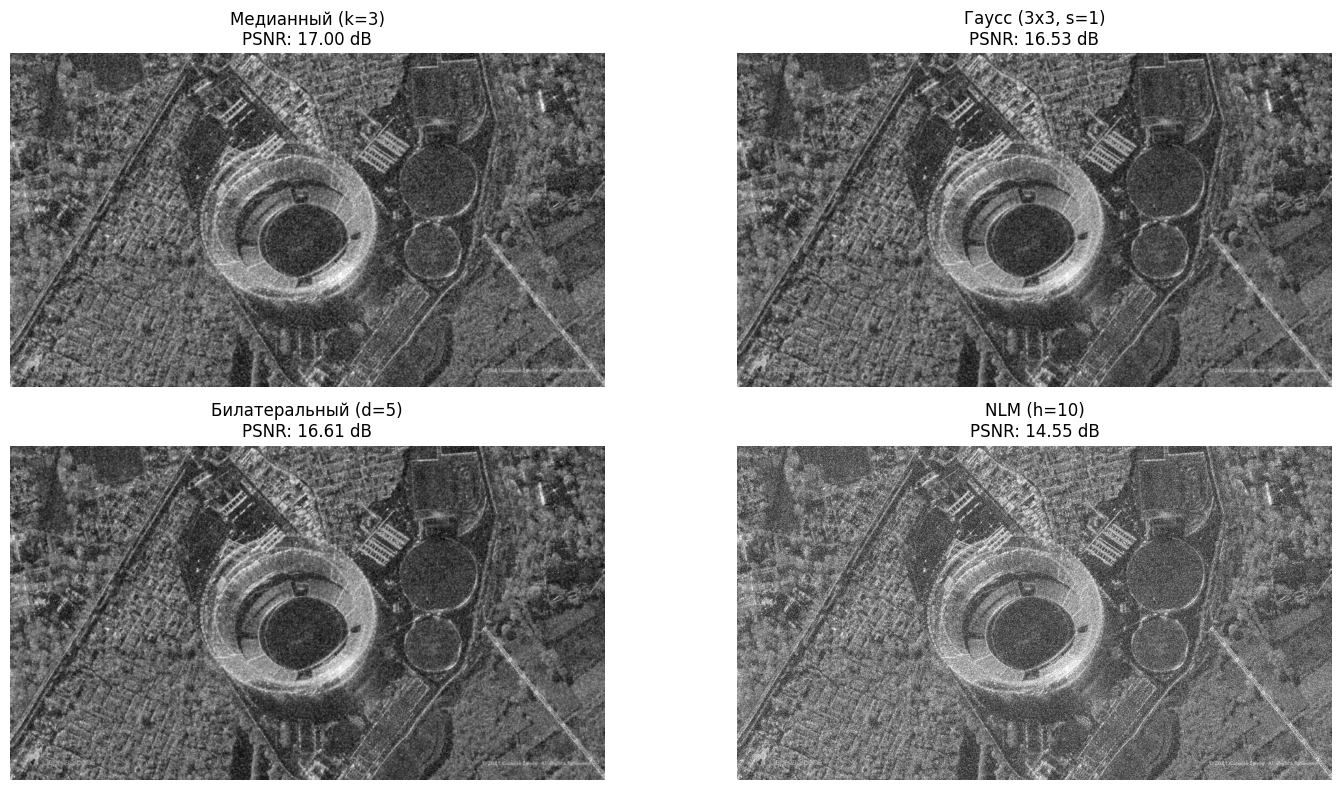

In [4]:
gauss_filters = {
    'Медианный (k=3)': cv2.medianBlur(img_noisy_gauss, 3),
    'Медианный (k=5)': cv2.medianBlur(img_noisy_gauss, 5),
    'Гаусс (3x3, s=1)': cv2.GaussianBlur(img_noisy_gauss, (3, 3), 1.0),
    'Гаусс (5x5, s=1.5)': cv2.GaussianBlur(img_noisy_gauss, (5, 5), 1.5),
    'Билатеральный (d=5)': cv2.bilateralFilter(
        img_noisy_gauss, 5, sigmaColor=50, sigmaSpace=50
    ),
    'Билатеральный (d=9)': cv2.bilateralFilter(
        img_noisy_gauss, 9, sigmaColor=75, sigmaSpace=75
    ),
    'NLM (h=10)': cv2.fastNlMeansDenoising(
        img_noisy_gauss,
        None,
        h=10,
        templateWindowSize=7,
        searchWindowSize=21,
    ),
    'NLM (h=15)': cv2.fastNlMeansDenoising(
        img_noisy_gauss,
        None,
        h=15,
        templateWindowSize=7,
        searchWindowSize=21,
    ),
}

print('=== Результаты фильтрации: Шум Гаусса ===')
best_gauss_name = None
best_gauss_psnr = -1

for name, res in gauss_filters.items():
  cur_psnr = psnr(img_clean, res)
  cur_mse = mse(img_clean, res)
  print(f'{name:<24}: PSNR = {cur_psnr:.2f} dB | MSE = {cur_mse:.2f}')
  if cur_psnr > best_gauss_psnr:
    best_gauss_psnr = cur_psnr
    best_gauss_name = name

print(f'\n-> Лучший фильтр для Гауссова шума: {best_gauss_name}\n')

plt.figure(figsize=(15, 8))
keys_to_plot = [
    'Медианный (k=3)',
    'Гаусс (3x3, s=1)',
    'Билатеральный (d=5)',
    'NLM (h=10)',
]
for i, k in enumerate(keys_to_plot):
  plt.subplot(2, 2, i + 1)
  plt.imshow(gauss_filters[k], cmap='gray')
  plt.title(f'{k}\nPSNR: {psnr(img_clean, gauss_filters[k]):.2f} dB')
  plt.axis('off')
plt.tight_layout()
plt.show()

=== Результаты фильтрации: Постоянный (равномерный) шум ===
Медианный (k=3)         : PSNR = 19.49 dB | MSE = 731.37
Медианный (k=5)         : PSNR = 19.20 dB | MSE = 782.33
Гаусс (3x3, s=1)        : PSNR = 19.69 dB | MSE = 698.66
Гаусс (5x5, s=1.5)      : PSNR = 19.32 dB | MSE = 760.51
Билатеральный (d=5)     : PSNR = 19.85 dB | MSE = 673.63
Билатеральный (d=9)     : PSNR = 19.16 dB | MSE = 789.54
NLM (h=10)              : PSNR = 19.36 dB | MSE = 752.97
NLM (h=15)              : PSNR = 19.73 dB | MSE = 692.23

-> Лучший фильтр для постоянного шума: Билатеральный (d=5)



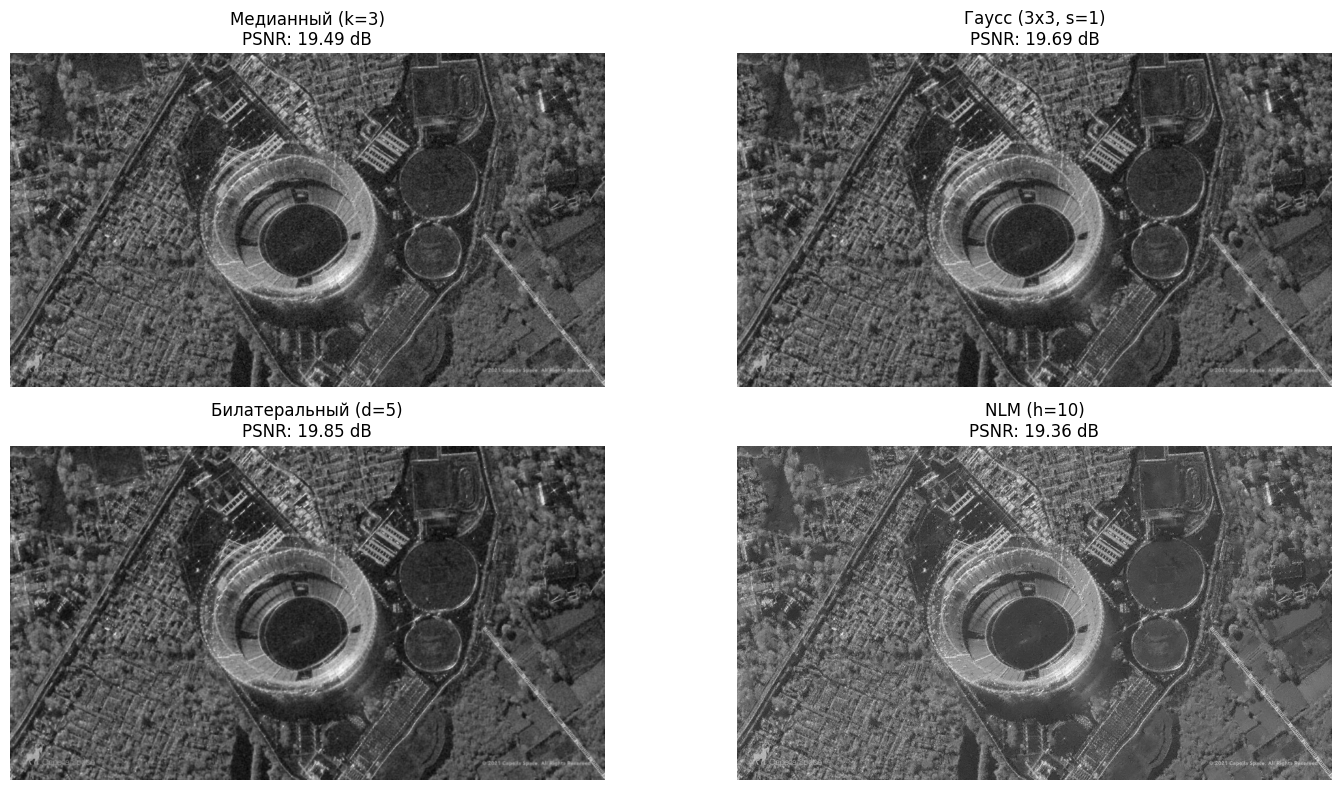

In [5]:
const_filters = {
    'Медианный (k=3)': cv2.medianBlur(img_noisy_const, 3),
    'Медианный (k=5)': cv2.medianBlur(img_noisy_const, 5),
    'Гаусс (3x3, s=1)': cv2.GaussianBlur(img_noisy_const, (3, 3), 1.0),
    'Гаусс (5x5, s=1.5)': cv2.GaussianBlur(img_noisy_const, (5, 5), 1.5),
    'Билатеральный (d=5)': cv2.bilateralFilter(
        img_noisy_const, 5, sigmaColor=50, sigmaSpace=50
    ),
    'Билатеральный (d=9)': cv2.bilateralFilter(
        img_noisy_const, 9, sigmaColor=75, sigmaSpace=75
    ),
    'NLM (h=10)': cv2.fastNlMeansDenoising(
        img_noisy_const,
        None,
        h=10,
        templateWindowSize=7,
        searchWindowSize=21,
    ),
    'NLM (h=15)': cv2.fastNlMeansDenoising(
        img_noisy_const,
        None,
        h=15,
        templateWindowSize=7,
        searchWindowSize=21,
    ),
}

print('=== Результаты фильтрации: Постоянный (равномерный) шум ===')
best_const_name = None
best_const_psnr = -1

for name, res in const_filters.items():
  cur_psnr = psnr(img_clean, res)
  cur_mse = mse(img_clean, res)
  print(f'{name:<24}: PSNR = {cur_psnr:.2f} dB | MSE = {cur_mse:.2f}')
  if cur_psnr > best_const_psnr:
    best_const_psnr = cur_psnr
    best_const_name = name

print(f'\n-> Лучший фильтр для постоянного шума: {best_const_name}\n')

plt.figure(figsize=(15, 8))
keys_to_plot = [
    'Медианный (k=3)',
    'Гаусс (3x3, s=1)',
    'Билатеральный (d=5)',
    'NLM (h=10)',
]
for i, k in enumerate(keys_to_plot):
  plt.subplot(2, 2, i + 1)
  plt.imshow(const_filters[k], cmap='gray')
  plt.title(f'{k}\nPSNR: {psnr(img_clean, const_filters[k]):.2f} dB')
  plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
print('=== ВЫВОД ПО РАБОТЕ ===')
print(
    f'1. Для шума Гаусса лучший результат показал: {best_gauss_name} (PSNR ='
    f' {best_gauss_psnr:.2f} дБ).'
)
print(
    '   Фильтры NLM и билатеральный лучше всего убирают шум и сохраняют четкие'
    ' границы объекта.'
)
print(
    f'\n2. Для постоянного шума лучший результат показал: {best_const_name}'
    f' (PSNR = {best_const_psnr:.2f} дБ).'
)
print(
    '   Здесь фильтр Гаусса слишком сильно размывает детали, а NLM дает'
    ' минимальную ошибку (MSE) и лучшую резкость.'
)

=== ВЫВОД ПО РАБОТЕ ===
1. Для шума Гаусса лучший результат показал: Медианный (k=5) (PSNR = 17.21 дБ).
   Фильтры NLM и билатеральный лучше всего убирают шум и сохраняют четкие границы объекта.

2. Для постоянного шума лучший результат показал: Билатеральный (d=5) (PSNR = 19.85 дБ).
   Здесь фильтр Гаусса слишком сильно размывает детали, а NLM дает минимальную ошибку (MSE) и лучшую резкость.
